In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Partie 1 : chargement et exploration

In [57]:
data = pd.read_csv('./titanic/train.csv')
data.head() # afficher les 5 premières lignes

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [58]:
data.dtypes # afficher les types de données

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [59]:
passagers = data.shape[0] # nombre de passager
print(f"Nombre de passager : {passagers}")

Nombre de passager : 891


In [60]:
survivants = data.loc[data['Survived'] == 1].shape[0]
print(f"Nombre de survivants : {survivants}")

Nombre de survivants : 342


In [61]:
proportion = survivants / passagers
print(f"Proportion : {proportion:.2f}")
print(f"Proportion : {data['Survived'].mean():.2f}")

Proportion : 0.38
Proportion : 0.38


##### Identifier les colonnes avec des valeurs manquantes

In [62]:
valeurs_manquantes = data.isnull().sum() # valeurs manquantes par colonne
pourcentages = 100 * (valeurs_manquantes / len(data))
colonnes_na = valeurs_manquantes[valeurs_manquantes > 0] # filtrer, enlever les colonnes qui n'ont pas de valeurs manquantes

df_valeurs_manquantes = pd.DataFrame({'valeurs_manquantes': colonnes_na, 'pourcentages': pourcentages[colonnes_na.index].round(2)})

In [63]:
df_valeurs_manquantes

,valeurs_manquantes,pourcentages
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


#### Partie 2 : Nettoyage et préparation

In [64]:
# imputer les valeurs manquantes : Age par la médiane, Embarked par la modalité la plus fréquente
age_mediane = data['Age'].median()
print(f"Médiane âge : {age_mediane}")

data['Age'] = data['Age'].fillna(age_mediane)

Médiane âge : 28.0


In [65]:
modalite_embarked = data['Embarked'].mode()[0] # modalité = valeur la plus fréquente
print(f"Modalité embarked : {modalite_embarked}")

data['Embarked'] = data['Embarked'].fillna(modalite_embarked)

Modalité embarked : S


In [66]:
print(data[['Age', 'Embarked']].isnull().sum()) # vérification des valeurs manquantes

Age         0
Embarked    0
dtype: int64


In [67]:
# supprimer les colonnes inutiles : PassengerId, Name, Ticket, Cabin. 
data['Title'] = data['Name'].str.extract(r',\s*([^\.]+)\.')

data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

* La colonne 'PassengerId' représente un identifiant unique pour chaque passager mais ne contient aucune information qui pourrait être utile à la prédiction
* La colonne 'Name' est un texte brut, donc n'apport aucune infomation pertinente ou utilise à la prédiction
* La colonne 'Ticket' contient des numéros de billets qui peuvent être incohérents, ces numéros sont très peu informatifs pour une prédiction de survie, surtout sans contexte
* La colonne 'Cabin' est la colonne qui contient le plus de valeurs manquantes parmi toutes les autres colonnes, donc difficiles à exploiter sans traitement de toutes ces valeurs manquantes

In [68]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,S,Mr
1,1,1,female,38.0,1,0,71.2833,C,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Miss
3,1,1,female,35.0,1,0,53.1000,S,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Mr


In [69]:
# Créer une nouvelle variable Title à partir de Name
n_data = pd.read_csv('./titanic/train.csv')
n_data['Title'] = n_data['Name'].str.extract(r',\s*([^\.]+)\.')
print(n_data['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64


* 'Title' indique le genre, la classe sociale et parfois l'âge du passage; cette colonne peut aider à améliorer la prédiction de survie

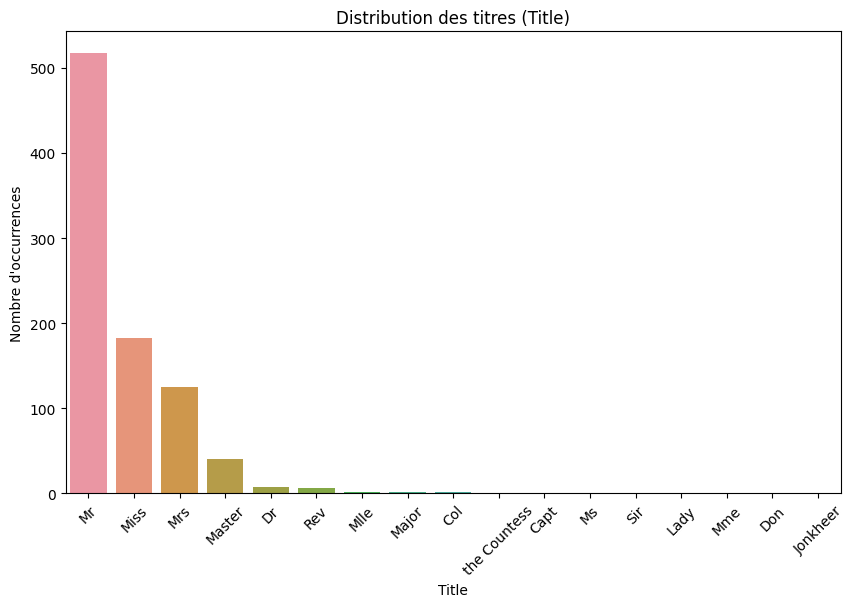

In [70]:
plt.figure(figsize=(10, 6))

sns.countplot(data=data, x='Title', order=data['Title'].value_counts().index)

plt.title("Distribution des titres (Title)")
plt.xlabel("Title")
plt.ylabel("Nombre d'occurrences")
plt.xticks(rotation=45)
plt.show()